# 0. Baixando os Datasets

Classificação supervisionada, 3.7k a 130k instâncias.

In [1]:
import warnings
from pathlib import Path

import openml
import pandas as pd

warnings.filterwarnings("ignore")

PASTA = Path("dados_openml")
PASTA.mkdir(exist_ok=True)

In [2]:
IDS = [
    6, 28, 30, 32, 44, 60, 151, 182, 183, 300, 554,
    1053, 1120, 1461, 1476, 1478, 1486, 1489, 1497, 1590,
    4134, 4534, 4538, 23517, 40668, 40685, 40701, 40996,
    41027, 41138, 41146, 41150, 41168,
]

linhas, falhas, ja_em_disco = [], [], []

for i, did in enumerate(IDS, 1):
    if next(PASTA.glob(f"{did}_*.parquet"), None):
        ja_em_disco.append(did)
        continue
    try:
        ds = openml.datasets.get_dataset(did)
        X, y, categoricos, _ = ds.get_data(target=ds.default_target_attribute)
        df = X.copy()
        df.columns = [str(c) for c in df.columns]
        df["target"] = y.values
        df.to_parquet(PASTA / f"{did}_{ds.name}.parquet", index=False)

        linhas.append([did, ds.name, len(df), X.shape[1], y.nunique(),
                       sum(categoricos), int(X.isna().sum().sum())])
        print(f"[{i:2}/{len(IDS)}] {ds.name[:34]:<34} {len(df):>7} x {X.shape[1]}")
    except Exception as e:
        falhas.append(did)
        print(f"[{i:2}/{len(IDS)}] {did} FALHOU: {e}")

print(f"{len(ja_em_disco)} ja em disco | {len(linhas)} baixados agora | {len(falhas)} falhas {falhas}")

33 ja em disco | 0 baixados agora | 0 falhas []


# 1. Meta Dataset

Um exemplo por dataset: as meta-características X, a performance P dos algoritmos e o rank R
derivado de P.

## Metafeatures

Convenções do OpenML: o alvo entra em `NumberOfFeatures` e conta como simbólico; percentuais em 0-100.
Atributos numéricos são discretizados em 10 faixas de igual frequência para as medidas de informação,
e valores faltantes viram uma faixa própria.

In [3]:
import numpy as np


def _entropia(s):
    p = s.value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())


def _entropia_conjunta(a, b):
    p = pd.DataFrame({"a": a, "b": b}).value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())


def _discretizar(coluna, faixas=10):
    if pd.api.types.is_numeric_dtype(coluna) and coluna.nunique() > faixas:
        codigos = pd.qcut(coluna, faixas, labels=False, duplicates="drop")
        return codigos.fillna(-1).astype("int16")
    return coluna.astype("category").cat.codes.astype("int16")

In [4]:
def mf_gerais(X, y):
    n, p = X.shape
    numericos = X.select_dtypes(include="number").shape[1]
    binarios = int((X.nunique(dropna=True) == 2).sum()) + int(y.nunique() == 2)
    return {
        "NumberOfInstances": n,
        "NumberOfFeatures": p + 1,
        "NumberOfClasses": int(y.nunique()),
        "NumberOfNumericFeatures": numericos,
        "NumberOfSymbolicFeatures": p - numericos + 1,
        "NumberOfBinaryFeatures": binarios,
        "NumberOfMissingValues": int(X.isna().sum().sum() + y.isna().sum()),
        "NumberOfInstancesWithMissingValues": int(X.isna().any(axis=1).sum()),
        "Dimensionality": (p + 1) / n,
    }


def mf_balanceamento(y):
    contagem = y.value_counts()
    contagem = contagem[contagem > 0]  # alvo categorico pode declarar classes sem nenhuma instancia
    return {
        "MajorityClassSize": int(contagem.max()),
        "MinorityClassSize": int(contagem.min()),
        "MajorityClassPercentage": 100 * contagem.max() / len(y),
        "MinorityClassPercentage": 100 * contagem.min() / len(y),
    }


def mf_estatisticas(X):
    num = X.select_dtypes(include="number")
    if num.empty:
        return dict.fromkeys(["MeanMeansOfNumericAtts", "MeanStdDevOfNumericAtts",
                              "MeanSkewnessOfNumericAtts", "MeanKurtosisOfNumericAtts"], np.nan)
    return {
        "MeanMeansOfNumericAtts": float(num.mean().mean()),
        "MeanStdDevOfNumericAtts": float(num.std().mean()),
        "MeanSkewnessOfNumericAtts": float(num.skew().mean()),
        "MeanKurtosisOfNumericAtts": float(num.kurtosis().mean()),
    }


def mf_informacao(X, y, faixas=10):
    alvo = y.astype("category").cat.codes
    h_classe = _entropia(alvo)

    entropias, informacoes = [], []
    for coluna in X.columns:
        atributo = _discretizar(X[coluna], faixas)
        h_atributo = _entropia(atributo)
        entropias.append(h_atributo)
        informacoes.append(h_atributo + h_classe - _entropia_conjunta(atributo, alvo))

    h_media, mi_media = float(np.mean(entropias)), float(np.mean(informacoes))
    return {
        "ClassEntropy": h_classe,
        "MeanAttributeEntropy": h_media,
        "MeanMutualInformation": mi_media,
        "EquivalentNumberOfAtts": h_classe / mi_media if mi_media > 0 else np.nan,
        "NoiseToSignalRatio": (h_media - mi_media) / mi_media if mi_media > 0 else np.nan,
    }


def mf_derivadas(mf):
    n, p = mf["NumberOfInstances"], mf["NumberOfFeatures"]
    return {
        "InstancesPerAttribute": n / p,
        "PercentageOfMissingValues": 100 * mf["NumberOfMissingValues"] / (n * p),
        "PercentageOfInstancesWithMissingValues": 100 * mf["NumberOfInstancesWithMissingValues"] / n,
        "PercentageOfNumericFeatures": 100 * mf["NumberOfNumericFeatures"] / p,
        "PercentageOfSymbolicFeatures": 100 * mf["NumberOfSymbolicFeatures"] / p,
        "PercentageOfBinaryFeatures": 100 * mf["NumberOfBinaryFeatures"] / p,
        "ClassImbalanceRatio": mf["MajorityClassSize"] / mf["MinorityClassSize"],
        "NormalizedClassEntropy": mf["ClassEntropy"] / np.log2(mf["NumberOfClasses"]),
        "LogInstances": np.log2(n),
        "LogFeatures": np.log2(p),
    }


def metafeatures(X, y):
    mf = {}
    mf.update(mf_gerais(X, y))
    mf.update(mf_balanceamento(y))
    mf.update(mf_estatisticas(X))
    mf.update(mf_informacao(X, y))
    mf.update(mf_derivadas(mf))
    return mf

In [5]:
import time

arquivos = sorted(PASTA.glob("*.parquet"))
CAMINHO_META = Path("metadataset.csv")
anterior = pd.read_csv(CAMINHO_META) if CAMINHO_META.exists() else None
prontos = set(anterior.did) if anterior is not None else set()

metadados = []

for i, arquivo in enumerate(arquivos, 1):
    did, nome = arquivo.stem.split("_", 1)
    if int(did) in prontos:
        continue
    inicio = time.perf_counter()
    df = pd.read_parquet(arquivo)

    linha = {"did": int(did), "nome": nome}
    linha.update(metafeatures(df.drop(columns="target"), df["target"]))
    metadados.append(linha)
    print(f"[{i:2}/{len(arquivos)}] {nome[:34]:<34} {time.perf_counter() - inicio:5.1f}s")

partes = [q for q in (anterior, pd.DataFrame(metadados)) if q is not None and not q.empty]
metadataset = (pd.concat(partes, ignore_index=True)
               .drop_duplicates(subset="did", keep="last")
               .sort_values("NumberOfInstances", ascending=False)
               .reset_index(drop=True))
metadataset.to_csv(CAMINHO_META, index=False)

print(f"{len(prontos)} ja calculados | {len(metadados)} novos")
print(f"metadataset.csv  {metadataset.shape[0]} datasets x {metadataset.shape[1] - 2} metafeatures")
metadataset

33 ja calculados | 0 novos
metadataset.csv  33 datasets x 32 metafeatures


,did,nome,NumberOfInstances,NumberOfFeatures,NumberOfClasses,NumberOfNumericFeatures,NumberOfSymbolicFeatures,NumberOfBinaryFeatures,NumberOfMissingValues,NumberOfInstancesWithMissingValues,...,InstancesPerAttribute,PercentageOfMissingValues,PercentageOfInstancesWithMissingValues,PercentageOfNumericFeatures,PercentageOfSymbolicFeatures,PercentageOfBinaryFeatures,ClassImbalanceRatio,NormalizedClassEntropy,LogInstances,LogFeatures
0,41150,MiniBooNE,130064,51,2,50,1,1,0,0,...,2550.274510,0.000000,0.000000,98.039216,1.960784,1.960784,2.563495,0.856299,16.988862,5.672425
1,23517,numerai28.6,96320,22,2,21,1,1,0,0,...,4378.181818,0.000000,0.000000,95.454545,4.545455,4.545455,1.020897,0.999923,16.555548,4.459432
2,41168,jannis,83733,55,4,54,1,0,0,0,...,1522.418182,0.000000,0.000000,98.181818,1.818182,0.000000,22.834618,0.799735,16.353509,5.781360
3,41138,APSFailure,76000,171,2,170,1,2,1078695,75244,...,444.444444,8.300208,99.005263,99.415205,0.584795,1.169591,54.272727,0.130590,16.213712,7.417853
4,40996,Fashion-MNIST,70000,785,10,784,1,0,0,0,...,89.171975,0.000000,0.000000,99.872611,0.127389,0.000000,1.000000,1.000000,16.095067,9.616549
5,554,mnist_784,70000,785,10,784,1,19,0,0,...,89.171975,0.000000,0.000000,99.872611,0.127389,2.420382,1.247743,0.999371,16.095067,9.616549
6,40668,connect-4,67557,43,3,0,43,0,0,0,...,1571.093023,0.000000,0.000000,0.000000,100.000000,0.000000,6.896108,0.768753,16.043818,5.426265
7,40685,shuttle,58000,10,7,9,1,0,0,0,...,5800.000000,0.000000,0.000000,90.000000,10.000000,0.000000,4558.600000,0.342066,15.823765,3.321928
8,1590,adult,48842,15,2,6,9,2,6465,3620,...,3256.133333,0.882437,7.411654,40.000000,60.000000,13.333333,3.179173,0.793844,15.575835,3.906891
9,151,electricity,45312,9,2,7,2,1,0,0,...,5034.666667,0.000000,0.000000,77.777778,22.222222,11.111111,1.355461,0.983509,15.467606,3.169925


## Performance — AUC por fold

**Métrica: AUC** (macro one-vs-rest quando multiclasse). Não depende do ponto de corte nem da
distribuição das classes — 20 dos 33 datasets são desbalanceados, e a acurácia premiaria a classe
majoritária. Por usar o ranking das probabilidades, separa melhor os algoritmos e empata menos,
o que importa para o teste pareado.

Os folds são os mesmos para todos os algoritmos de um dataset, então a comparação é pareada.
`performance_folds.csv` guarda o valor de cada fold; `matriz_performance.csv` é só a média.

In [6]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

N_FOLDS = 10
N_MAX = 10_000
SEMENTE = 42

ALGORITMOS = {
    "logreg": LogisticRegression(max_iter=1000),
    "nb": GaussianNB(),
    "knn": KNeighborsClassifier(n_jobs=-1),
    "tree": DecisionTreeClassifier(random_state=SEMENTE),
    "rf": RandomForestClassifier(n_estimators=100, random_state=SEMENTE, n_jobs=-1),
    "hgb": HistGradientBoostingClassifier(random_state=SEMENTE),
}

In [7]:
def _preparar(X, y):
    if len(y) > N_MAX:
        X, _, y, _ = train_test_split(X, y, train_size=N_MAX, stratify=y, random_state=SEMENTE)
    frequentes = y.value_counts()  # depois da subamostragem: uma classe rara pode encolher abaixo de N_FOLDS
    y = y[y.isin(frequentes[frequentes >= N_FOLDS].index)]
    X = X.loc[y.index]
    return X.reset_index(drop=True), y.reset_index(drop=True)


def _preprocessador(X):
    numericos = X.select_dtypes(include="number").columns
    simbolicos = X.columns.difference(numericos)
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("esc", StandardScaler())]), numericos),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), simbolicos),
    ])


def _auc(y_teste, probabilidades, classes):
    if len(classes) == 2:
        return roc_auc_score(y_teste, probabilidades[:, 1])
    return roc_auc_score(y_teste, probabilidades, multi_class="ovr",
                         average="macro", labels=classes)

In [8]:
CAMINHO_FOLDS = Path("performance_folds.csv")
arquivos = sorted(PASTA.glob("*.parquet"))

if CAMINHO_FOLDS.exists():
    anteriores = pd.read_csv(CAMINHO_FOLDS).dropna(subset=["auc"])
    contagem = anteriores.groupby(["did", "algoritmo"]).fold.count()
    completos = set(contagem[contagem == N_FOLDS].index)
else:
    anteriores, completos = None, set()

registros = []

for i, arquivo in enumerate(arquivos, 1):
    did, nome = arquivo.stem.split("_", 1)
    did = int(did)
    pendentes = [chave for chave in ALGORITMOS if (did, chave) not in completos]
    if not pendentes:
        print(f"[{i:2}/{len(arquivos)}] {nome[:30]:<30} completo")
        continue

    df = pd.read_parquet(arquivo)
    X, y = _preparar(df.drop(columns="target"), df["target"])
    particoes = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEMENTE).split(X, y))
    print(f"[{i:2}/{len(arquivos)}] {nome[:30]:<30} {X.shape[0]:>6} x {X.shape[1]:<5}", end=" ", flush=True)

    for chave in pendentes:
        inicio = time.perf_counter()
        try:
            avaliacoes = []
            for fold, (treino, teste) in enumerate(particoes):
                modelo = Pipeline([("pre", _preprocessador(X)), ("clf", clone(ALGORITMOS[chave]))])
                modelo.fit(X.iloc[treino], y.iloc[treino])
                probabilidades = modelo.predict_proba(X.iloc[teste])
                avaliacoes.append({"did": did, "nome": nome, "algoritmo": chave, "fold": fold,
                                   "auc": _auc(y.iloc[teste], probabilidades, modelo.classes_)})
            media = np.mean([a["auc"] for a in avaliacoes])
            if np.isnan(media):  # sem AUC definida os folds nao entram, e o par volta na proxima execucao
                print(f"{chave} AUC INDEFINIDA", end="  ", flush=True)
            else:
                registros.extend(avaliacoes)
                print(f"{chave} {media:.3f} ({time.perf_counter() - inicio:.0f}s)", end="  ", flush=True)
        except Exception as e:
            print(f"{chave} FALHOU ({type(e).__name__})", end="  ", flush=True)
    print()

    salvar = [q for q in (anteriores, pd.DataFrame(registros)) if q is not None and not q.empty]
    if salvar:
        (pd.concat(salvar, ignore_index=True)
           .sort_values(["did", "algoritmo", "fold"])
           .to_csv(CAMINHO_FOLDS, index=False))

[ 1/33] jm1                            completo
[ 2/33] MagicTelescope                 completo
[ 3/33] bank-marketing                 completo
[ 4/33] gas-drift                      completo
[ 5/33] har                            completo
[ 6/33] nomao                          completo
[ 7/33] phoneme                        completo
[ 8/33] wall-robot-navigation          completo
[ 9/33] electricity                    completo
[10/33] adult                          completo
[11/33] satimage                       completo
[12/33] abalone                        completo
[13/33] numerai28.6                    completo
[14/33] optdigits                      completo
[15/33] isolet                         completo
[16/33] page-blocks                    completo
[17/33] pendigits                      completo
[18/33] connect-4                      completo
[19/33] shuttle                        completo
[20/33] churn                          completo
[21/33] Fashion-MNIST                  c

In [9]:
folds = pd.read_csv("performance_folds.csv")
P = folds.pivot_table(index=["did", "nome"], columns="algoritmo", values="auc", aggfunc="mean")
P = P[list(ALGORITMOS)]
P.to_csv("matriz_performance.csv")

print(f"{len(folds)} avaliacoes = {P.shape[0]} datasets x {P.shape[1]} algoritmos x {N_FOLDS} folds")
print(f"vencedor por dataset:\n{P.idxmax(axis=1).value_counts().to_string()}")
P.round(4)

1980 avaliacoes = 33 datasets x 6 algoritmos x 10 folds
vencedor por dataset:
hgb       21
rf         8
logreg     3
nb         1


,algoritmo,logreg,nb,knn,tree,rf,hgb
did,nome,,,,,,
6,letter,0.9790,0.9559,0.9930,0.9172,0.9989,0.9993
28,optdigits,0.9992,0.9773,0.9970,0.9496,0.9997,0.9997
30,page-blocks,0.9796,0.9612,0.9481,0.8865,0.9886,0.8533
32,pendigits,0.9974,0.9802,0.9987,0.9788,0.9997,0.9997
44,spambase,0.9711,0.9308,0.9530,0.9089,0.9874,0.9894
60,waveform-5000,0.9708,0.9560,0.9201,0.8075,0.9675,0.9677
151,electricity,0.8238,0.7864,0.8586,0.8166,0.9361,0.9370
182,satimage,0.9767,0.9558,0.9804,0.9039,0.9904,0.9917
183,abalone,0.8408,0.7505,0.6512,0.5521,0.7784,0.7064


## 1.1 A matriz de performances P

In [10]:
P = pd.read_csv("matriz_performance.csv", index_col=["did", "nome"]).sort_index()
P.round(4)

,,logreg,nb,knn,tree,rf,hgb
did,nome,,,,,,
6,letter,0.9790,0.9559,0.9930,0.9172,0.9989,0.9993
28,optdigits,0.9992,0.9773,0.9970,0.9496,0.9997,0.9997
30,page-blocks,0.9796,0.9612,0.9481,0.8865,0.9886,0.8533
32,pendigits,0.9974,0.9802,0.9987,0.9788,0.9997,0.9997
44,spambase,0.9711,0.9308,0.9530,0.9089,0.9874,0.9894
60,waveform-5000,0.9708,0.9560,0.9201,0.8075,0.9675,0.9677
151,electricity,0.8238,0.7864,0.8586,0.8166,0.9361,0.9370
182,satimage,0.9767,0.9558,0.9804,0.9039,0.9904,0.9917
183,abalone,0.8408,0.7505,0.6512,0.5521,0.7784,0.7064


In [11]:
quadro_algoritmos = pd.DataFrame(
    [{"chave": chave, "algoritmo": type(modelo).__name__,
      "ajustes": ", ".join(f"{k}={v}" for k, v in modelo.get_params().items()
                           if v != type(modelo)().get_params()[k]
                           and k not in ("n_jobs", "random_state")) or "padrão"}
     for chave, modelo in ALGORITMOS.items()])

print("Quadro 1 — os 6 algoritmos. Pré-processamento identico para todos: "
      "imputação, one-hot nos simbólicos, padronização nos numéricos")
quadro_algoritmos

Quadro 1 — os 6 algoritmos. Pré-processamento identico para todos: imputação, one-hot nos simbólicos, padronização nos numéricos


,chave,algoritmo,ajustes
0,logreg,LogisticRegression,max_iter=1000
1,nb,GaussianNB,padrão
2,knn,KNeighborsClassifier,padrão
3,tree,DecisionTreeClassifier,padrão
4,rf,RandomForestClassifier,padrão
5,hgb,HistGradientBoostingClassifier,padrão


## 1.2 As meta-características X

In [12]:
X = pd.read_csv("metadataset.csv", index_col=["did", "nome"]).sort_index()
X

,,NumberOfInstances,NumberOfFeatures,NumberOfClasses,NumberOfNumericFeatures,NumberOfSymbolicFeatures,NumberOfBinaryFeatures,NumberOfMissingValues,NumberOfInstancesWithMissingValues,Dimensionality,MajorityClassSize,...,InstancesPerAttribute,PercentageOfMissingValues,PercentageOfInstancesWithMissingValues,PercentageOfNumericFeatures,PercentageOfSymbolicFeatures,PercentageOfBinaryFeatures,ClassImbalanceRatio,NormalizedClassEntropy,LogInstances,LogFeatures
did,nome,,,,,,,,,,,,,,,,,,,,,
6,letter,20000,17,26,16,1,0,0,0,0.000850,813,...,1176.470588,0.000000,0.000000,94.117647,5.882353,0.000000,1.107629,0.999866,14.287712,4.087463
28,optdigits,5620,65,10,64,1,3,0,0,0.011566,572,...,86.461538,0.000000,0.000000,98.461538,1.538462,4.615385,1.032491,0.999971,12.456354,6.022368
30,page-blocks,5473,11,5,10,1,0,0,0,0.002010,4913,...,497.545455,0.000000,0.000000,90.909091,9.090909,0.000000,175.464286,0.273679,12.418116,3.459432
32,pendigits,10992,17,10,16,1,0,0,0,0.001547,1144,...,646.588235,0.000000,0.000000,94.117647,5.882353,0.000000,1.084360,0.999652,13.424166,4.087463
44,spambase,4601,58,2,57,1,1,0,0,0.012606,2788,...,79.327586,0.000000,0.000000,98.275862,1.724138,1.724138,1.537783,0.967360,12.167732,5.857981
60,waveform-5000,5000,41,3,40,1,0,0,0,0.008200,1692,...,121.951220,0.000000,0.000000,97.560976,2.439024,0.000000,1.023593,0.999947,12.287712,5.357552
151,electricity,45312,9,2,7,2,1,0,0,0.000199,26075,...,5034.666667,0.000000,0.000000,77.777778,22.222222,11.111111,1.355461,0.983509,15.467606,3.169925
182,satimage,6430,37,6,36,1,0,0,0,0.005754,1531,...,173.783784,0.000000,0.000000,97.297297,2.702703,0.000000,2.449600,0.960696,12.650603,5.209453
183,abalone,4177,9,28,7,2,0,0,0,0.002155,689,...,464.111111,0.000000,0.000000,77.777778,22.222222,0.000000,689.000000,0.749270,12.028251,3.169925


In [13]:
quadro_datasets = (X.reset_index()[["did", "nome", "NumberOfInstances", "NumberOfFeatures",
                                    "NumberOfClasses", "MajorityClassPercentage",
                                    "NumberOfMissingValues"]]
                   .sort_values("did").reset_index(drop=True))
quadro_datasets.columns = ["id", "dataset", "instâncias", "atributos", "classes",
                           "% majoritária", "faltantes"]
quadro_datasets["% majoritária"] = quadro_datasets["% majoritária"].round(1)

print(f"Quadro 2 — os {len(quadro_datasets)} datasets. id remete a openml.org/d/<id>")
quadro_datasets

Quadro 2 — os 33 datasets. id remete a openml.org/d/<id>


,id,dataset,instâncias,atributos,classes,% majoritária,faltantes
0,6,letter,20000,17,26,4.1,0
1,28,optdigits,5620,65,10,10.2,0
2,30,page-blocks,5473,11,5,89.8,0
3,32,pendigits,10992,17,10,10.4,0
4,44,spambase,4601,58,2,60.6,0
5,60,waveform-5000,5000,41,3,33.8,0
6,151,electricity,45312,9,2,57.5,0
7,182,satimage,6430,37,6,23.8,0
8,183,abalone,4177,9,28,16.5,0
9,300,isolet,7797,618,26,3.8,0


In [14]:
_amostra = pd.read_parquet(sorted(PASTA.glob("*.parquet"))[0])
_ax, _ay = _amostra.drop(columns="target"), _amostra["target"]

FAMILIAS = {  # derivadas das proprias funcoes, para nao sair de sincronia com o codigo
    "Gerais / dimensão": list(mf_gerais(_ax, _ay)),
    "Balanceamento": list(mf_balanceamento(_ay)),
    "Estatísticas": list(mf_estatisticas(_ax)),
    "Teoria da informação": list(mf_informacao(_ax, _ay)),
    "Derivadas": list(mf_derivadas(metafeatures(_ax, _ay))),
}

quadro_metafeatures = pd.DataFrame(
    [{"família": familia, "n": len(nomes), "meta-características": ", ".join(nomes)}
     for familia, nomes in FAMILIAS.items()])

print(f"Quadro 3 — as {sum(len(v) for v in FAMILIAS.values())} meta-características por família")
quadro_metafeatures

Quadro 3 — as 32 meta-características por família


,família,n,meta-características
0,Gerais / dimensão,9,"NumberOfInstances, NumberOfFeatures, NumberOfC..."
1,Balanceamento,4,"MajorityClassSize, MinorityClassSize, Majority..."
2,Estatísticas,4,"MeanMeansOfNumericAtts, MeanStdDevOfNumericAtt..."
3,Teoria da informação,5,"ClassEntropy, MeanAttributeEntropy, MeanMutual..."
4,Derivadas,10,"InstancesPerAttribute, PercentageOfMissingValu..."


In [15]:
FORMULAS = {  # n = NumberOfInstances, p = NumberOfFeatures
    "InstancesPerAttribute": "n / p",
    "PercentageOfMissingValues": "100 · NumberOfMissingValues / (n · p)",
    "PercentageOfInstancesWithMissingValues": "100 · NumberOfInstancesWithMissingValues / n",
    "PercentageOfNumericFeatures": "100 · NumberOfNumericFeatures / p",
    "PercentageOfSymbolicFeatures": "100 · NumberOfSymbolicFeatures / p",
    "PercentageOfBinaryFeatures": "100 · NumberOfBinaryFeatures / p",
    "ClassImbalanceRatio": "MajorityClassSize / MinorityClassSize",
    "NormalizedClassEntropy": "ClassEntropy / log2(NumberOfClasses)",
    "LogInstances": "log2(n)",
    "LogFeatures": "log2(p)",
}
assert list(FORMULAS) == FAMILIAS["Derivadas"]  # trava contra sair de sincronia com mf_derivadas

quadro_formulas = pd.DataFrame({"meta-característica": list(FORMULAS),
                                "fórmula": list(FORMULAS.values())})

print("Quadro 4 — fórmulas das 10 derivadas, com n = NumberOfInstances e p = NumberOfFeatures")
quadro_formulas

Quadro 4 — fórmulas das 10 derivadas, com n = NumberOfInstances e p = NumberOfFeatures


,meta-característica,fórmula
0,InstancesPerAttribute,n / p
1,PercentageOfMissingValues,100 · NumberOfMissingValues / (n · p)
2,PercentageOfInstancesWithMissingValues,100 · NumberOfInstancesWithMissingValues / n
3,PercentageOfNumericFeatures,100 · NumberOfNumericFeatures / p
4,PercentageOfSymbolicFeatures,100 · NumberOfSymbolicFeatures / p
5,PercentageOfBinaryFeatures,100 · NumberOfBinaryFeatures / p
6,ClassImbalanceRatio,MajorityClassSize / MinorityClassSize
7,NormalizedClassEntropy,ClassEntropy / log2(NumberOfClasses)
8,LogInstances,log2(n)
9,LogFeatures,log2(p)


## 1.3 A matriz de ranks R

Rank 1 = melhor, empates com rank médio. O empate aqui é estatístico: cada par de algoritmos é
comparado por **Wilcoxon signed-rank pareado sobre os 10 folds** — o mesmo fold para os dois, que é
a razão de guardar `performance_folds.csv` em vez da média. Sem isso uma vantagem de 0.00001 de AUC
valeria rank 1, e sem suposição de normalidade das diferenças, que com 10 folds não se verifica.

O rank sai da contagem de vitórias significativas ao nível `ALFA` (0 a 5): dois algoritmos sem
diferença significativa no topo ficam ambos com 1.5. `matriz_vitorias.csv` guarda as contagens,
`matriz_ranks.csv` o R.

Dois cuidados que o teste exige. O p-valor bilateral exato do Wilcoxon com `n` pares nunca é menor
que `2 / 2**n` — com 10 folds o piso é 0.00195, então um `ALFA` de 0.001 tornaria todo empate
inevitável sem nenhum aviso. E folds ausentes reduzem `n`: cada par usa só os folds válidos nos
dois, e datasets sem folds suficientes ficam de fora em vez de entrarem como um empate geral falso.

In [16]:
import itertools

from scipy import stats

ALFA = 0.05


def _folds_minimos(alfa):
    n = 1
    while 2 / 2 ** n > alfa:  # menor p bilateral exato do Wilcoxon com n pares
        n += 1
    return n


N_MINIMO = _folds_minimos(ALFA)
if N_MINIMO > N_FOLDS:
    print(f"ATENCAO: com {N_FOLDS} folds o menor p possivel e {2 / 2 ** N_FOLDS:.5f}; "
          f"nada sera significativo a alfa={ALFA}, que precisaria de {N_MINIMO} folds.")
else:
    print(f"alfa={ALFA} exige ao menos {N_MINIMO} folds pareados; ha {N_FOLDS}.")


def _comparar(x, y):
    validos = ~(np.isnan(x) | np.isnan(y))
    if validos.sum() < N_MINIMO:
        return 1.0, 0.0
    x, y = x[validos], y[validos]
    return float(stats.wilcoxon(x, y, zero_method="pratt").pvalue), float(np.median(x - y))


def vitorias_significativas(por_fold):
    vitorias = pd.Series(0, index=por_fold.columns, dtype=int)
    for a, b in itertools.combinations(por_fold.columns, 2):
        p_valor, diferenca = _comparar(por_fold[a].to_numpy(), por_fold[b].to_numpy())
        if p_valor < ALFA and diferenca != 0:
            vitorias[a if diferenca > 0 else b] += 1
    return vitorias

alfa=0.05 exige ao menos 6 folds pareados; ha 10.


In [17]:
folds = pd.read_csv("performance_folds.csv")
algoritmos = list(P.columns)

contagens, descartados = {}, []
for chave, grupo in folds.groupby(["did", "nome"]):
    por_fold = grupo.pivot(index="fold", columns="algoritmo", values="auc")[algoritmos]
    if (por_fold.notna().sum() < N_MINIMO).any():
        descartados.append(chave[0])
        continue
    contagens[chave] = vitorias_significativas(por_fold)

V = pd.DataFrame(contagens).T.rename_axis(["did", "nome"])
V.to_csv("matriz_vitorias.csv")

R = V.rank(axis=1, ascending=False, method="average")
R.to_csv("matriz_ranks.csv")

if descartados:
    print(f"ATENCAO: {len(descartados)} dataset(s) sem folds suficientes, fora de V e R: {descartados}")
print(f"{int(V.sum().sum())} vitorias significativas de {V.shape[0] * 15} comparacoes")
print(f"{int((R % 1 != 0).sum().sum())} empates de {R.size} celulas")
print(f"rank medio:\n{R.mean().sort_values().round(2).to_string()}")
R

443 vitorias significativas de 495 comparacoes
66 empates de 198 celulas
rank medio:
algoritmo
hgb       1.77
rf        1.91
logreg    3.33
knn       3.85
nb        4.85
tree      5.29


,algoritmo,logreg,nb,knn,tree,rf,hgb
did,nome,,,,,,
6,letter,4.0,5.0,3.0,6.0,2.0,1.0
28,optdigits,3.0,5.0,4.0,6.0,1.5,1.5
30,page-blocks,1.5,3.5,3.5,5.5,1.5,5.5
32,pendigits,4.0,5.5,3.0,5.5,1.5,1.5
44,spambase,3.0,5.5,4.0,5.5,2.0,1.0
60,waveform-5000,1.0,4.0,5.0,6.0,2.5,2.5
151,electricity,4.0,6.0,3.0,5.0,1.5,1.5
182,satimage,4.0,5.0,3.0,6.0,2.0,1.0
183,abalone,1.0,3.0,4.5,6.0,2.0,4.5


# 2. As abordagens

Cada abordagem recebe os 32 datasets de treino da rodada e devolve um vetor de ranks previsto para
o dataset deixado de fora. Assinatura única, para o laço de avaliação tratar todas igual.

In [18]:
from collections import namedtuple
from functools import partial

from sklearn.ensemble import RandomForestRegressor

V = pd.read_csv("matriz_vitorias.csv", index_col=["did", "nome"]).sort_index()
R = pd.read_csv("matriz_ranks.csv", index_col=["did", "nome"]).sort_index()
assert list(X.index) == list(P.index) == list(R.index) == list(V.index)

META = [c for c in X.columns]
Xn, Pn, Rn, Vn = X[META].to_numpy(float), P.to_numpy(), R.to_numpy(), V.to_numpy()
n_datasets, n_algos = Pn.shape

Rodada = namedtuple("Rodada", "Xtr Ptr Rtr Vtr xte")


def _ranquear(v):
    ordem = np.argsort(v, kind="stable")
    ranks = np.empty(len(v))
    ranks[ordem] = np.arange(1.0, len(v) + 1)
    _, inversa, contagem = np.unique(v, return_inverse=True, return_counts=True)
    if len(contagem) < len(v):  # empates recebem o rank medio
        ranks = (np.bincount(inversa, weights=ranks) / contagem)[inversa]
    return ranks


print(f"X {Xn.shape} | P {Pn.shape} | R {Rn.shape} | V {Vn.shape}")

X (33, 32) | P (33, 6) | R (33, 6) | V (33, 6)


## 2.1 Agregação de rankings

Um ranking fixo por rodada, igual para todos os datasets. Não usam X.

In [19]:
def ar(d):
    return _ranquear(d.Rtr.mean(axis=0))


def mr(d):
    return _ranquear(np.median(d.Rtr, axis=0))


def vs(d):
    return _ranquear(-d.Vtr.sum(axis=0))  # mais vitorias, melhor rank

## 2.2 Meta-modelos treinados

`RandomForestRegressor` aceita alvo multi-saída nativamente. A imputação dos NaN de X é feita no
laço de avaliação, com a mediana dos 32 de treino.

In [20]:
def _floresta(d, alvo):
    modelo = RandomForestRegressor(n_estimators=200, min_samples_leaf=3,
                                   random_state=SEMENTE, n_jobs=-1)
    modelo.fit(d.Xtr, alvo)
    return modelo.predict(d.xte.reshape(1, -1))[0]


def reg_p(d):
    return _ranquear(-_floresta(d, d.Ptr))  # maior AUC prevista, melhor rank


def reg_r(d):
    return _ranquear(_floresta(d, d.Rtr))

## 2.3 HARRIS

Floresta em que cada split minimiza `L = λ·L_ranking + (1−λ)·L_regressão`.

`L_regressão` é o erro quadrático médio das performances em torno da média do nó; `L_ranking` é a
média de `1 − ρ_Spearman(r_i, consenso do nó)`.

Duas normalizações sustentam o λ. P é normalizado **por dataset** (min-max na linha), senão um
dataset com amplitude de AUC de 0.475 domina outro de 0.020 — e a normalização por linha não vaza
nada, já que usa só os valores do próprio dataset. E cada perda é dividida pelo seu valor na raiz
da árvore, senão as duas ficam em escalas diferentes (`L_regressão` ~0.001, `L_ranking` ~1) e
λ=0.5 seria efetivamente λ=1.

λ=0 é árvore de regressão pura sobre P, λ=1 árvore de ranking pura.

In [21]:
def _perda_regressao(Pm):
    return float(((Pm - Pm.mean(axis=0)) ** 2).mean())


def _perda_ranking(Rm):
    consenso = _ranquear(Rm.mean(axis=0))
    a = Rm - Rm.mean(axis=1, keepdims=True)
    b = consenso - consenso.mean()
    den = np.sqrt((a ** 2).sum(axis=1) * (b ** 2).sum())
    rho = np.divide(a @ b, den, out=np.zeros(len(Rm)), where=den > 0)
    return float(np.mean(1 - rho))


class ArvoreHarris:
    def __init__(self, lam, min_folha=3, max_prof=3, mtry=5, n_cortes=10, semente=0):
        self.lam, self.min_folha, self.max_prof = lam, min_folha, max_prof
        self.mtry, self.n_cortes = mtry, n_cortes
        self.rng = np.random.default_rng(semente)

    def treinar(self, X, Pnorm, R, idx):
        self.X, self.Pnorm, self.R = X, Pnorm, R
        self.escala = (max(_perda_regressao(Pnorm[idx]), 1e-12),
                       max(_perda_ranking(R[idx]), 1e-12))
        self.raiz = self._crescer(idx, self.max_prof)
        return self

    def _custo(self, idx):
        return (self.lam * _perda_ranking(self.R[idx]) / self.escala[1]
                + (1 - self.lam) * _perda_regressao(self.Pnorm[idx]) / self.escala[0])

    def _crescer(self, idx, prof):
        if prof == 0 or len(idx) < 2 * self.min_folha:
            return self.R[idx].mean(axis=0)

        melhor, corte = np.inf, None
        for f in self.rng.choice(self.X.shape[1], self.mtry, replace=False):
            valores = np.unique(self.X[idx, f])
            if len(valores) < 2:
                continue
            for limiar in np.unique(np.quantile(valores, np.linspace(0, 1, self.n_cortes + 2)[1:-1])):
                esquerda = self.X[idx, f] <= limiar
                if esquerda.sum() < self.min_folha or (~esquerda).sum() < self.min_folha:
                    continue
                custo = (esquerda.sum() * self._custo(idx[esquerda])
                         + (~esquerda).sum() * self._custo(idx[~esquerda])) / len(idx)
                if custo < melhor:
                    melhor, corte = custo, (f, limiar, esquerda)

        if corte is None:
            return self.R[idx].mean(axis=0)
        f, limiar, esquerda = corte
        return (f, limiar,
                self._crescer(idx[esquerda], prof - 1),
                self._crescer(idx[~esquerda], prof - 1))

    def prever(self, x):
        no = self.raiz
        while isinstance(no, tuple):
            no = no[2] if x[no[0]] <= no[1] else no[3]
        return no


class FlorestaHarris:
    def __init__(self, lam, n_arvores=100, semente=SEMENTE, **kw):
        self.lam, self.n_arvores, self.semente, self.kw = lam, n_arvores, semente, kw

    def treinar(self, X, Pbruto, R):
        piso = Pbruto.min(axis=1, keepdims=True)
        amplitude = Pbruto.max(axis=1, keepdims=True) - piso
        Pnorm = (Pbruto - piso) / np.where(amplitude > 0, amplitude, 1.0)

        rng = np.random.default_rng(self.semente)
        self.arvores = []
        for _ in range(self.n_arvores):
            bolsa = rng.choice(len(X), len(X), replace=True)
            arvore = ArvoreHarris(self.lam, semente=int(rng.integers(1 << 31)), **self.kw)
            self.arvores.append(arvore.treinar(X, Pnorm, R, bolsa))
        return self

    def prever(self, x):
        return _ranquear(np.mean([a.prever(x) for a in self.arvores], axis=0))


def harris(d, lam):
    return FlorestaHarris(lam).treinar(d.Xtr, d.Ptr, d.Rtr).prever(d.xte)

In [22]:
LAMBDAS = [0.0, 0.25, 0.5, 0.75, 1.0]
LAMBDA_DC = 0.5  # o lambda que entra no diagrama de diferenca critica, escolhido antes de ver o resultado

ABORDAGENS = {
    "AR": ar,
    "MR": mr,
    "VS": vs,
    "reg-P": reg_p,
    "reg-R": reg_r,
    **{f"HARRIS λ={lam:.2f}": partial(harris, lam=lam) for lam in LAMBDAS},
}
SEIS = ["AR", "MR", "VS", "reg-P", "reg-R", f"HARRIS λ={LAMBDA_DC:.2f}"]

print(f"{len(ABORDAGENS)} variantes | as seis do diagrama: {SEIS}")

10 variantes | as seis do diagrama: ['AR', 'MR', 'VS', 'reg-P', 'reg-R', 'HARRIS λ=0.50']


In [23]:
quadro_abordagens = pd.DataFrame(
    [("AR", "não", "média das colunas de R, reordenada"),
     ("MR", "não", "mediana das colunas de R"),
     ("VS", "não", "soma das vitórias significativas sobre os 32 datasets de treino"),
     ("reg-P", "sim", "random forest multi-saída sobre P; ranking pela AUC prevista, decrescente"),
     ("reg-R", "sim", "random forest multi-saída sobre R; ranking pelas posições previstas"),
     ("HARRIS", "sim", "floresta com split por L = λ·L_ranking + (1−λ)·L_regressão")],
    columns=["abordagem", "usa X", "como"])

print("Quadro 5 — as seis abordagens. As três primeiras produzem um ranking fixo por rodada, "
      "igual para todos os datasets; os regressores são random forests de 200 árvores")
quadro_abordagens

Quadro 5 — as seis abordagens. As três primeiras produzem um ranking fixo por rodada, igual para todos os datasets; os regressores são random forests de 200 árvores


,abordagem,usa X,como
0,AR,não,"média das colunas de R, reordenada"
1,MR,não,mediana das colunas de R
2,VS,não,soma das vitórias significativas sobre os 32 d...
3,reg-P,sim,random forest multi-saída sobre P; ranking pel...
4,reg-R,sim,random forest multi-saída sobre R; ranking pel...
5,HARRIS,sim,floresta com split por L = λ·L_ranking + (1−λ)...


# 3. Avaliação experimental

Leave-one-dataset-out. Tudo que uma abordagem usa sai dos 32 datasets de treino da rodada — a
agregação, a imputação de X e o treino dos modelos. As 33 partições são as mesmas para todas as
abordagens, condição para o Friedman da Seção 3.2 ser pareado.

`previsoes.csv` guarda o ranking previsto por abordagem e por dataset; as métricas saem dele.

In [24]:
CAMINHO_PREV = Path("previsoes.csv")

rodadas = []
for i in range(n_datasets):
    treino = np.delete(np.arange(n_datasets), i)
    mediana = np.nanmedian(Xn[treino], axis=0)  # imputacao ajustada so no treino
    rodadas.append((i, Rodada(Xtr=np.where(np.isnan(Xn[treino]), mediana, Xn[treino]),
                              Ptr=Pn[treino], Rtr=Rn[treino], Vtr=Vn[treino],
                              xte=np.where(np.isnan(Xn[i]), mediana, Xn[i]))))

if CAMINHO_PREV.exists():
    anteriores = pd.read_csv(CAMINHO_PREV)
    prontas = set(anteriores.abordagem)
else:
    anteriores, prontas = None, set()

registros = []
for nome_abordagem, funcao in ABORDAGENS.items():
    if nome_abordagem in prontas:
        print(f"{nome_abordagem:<18} ja calculada")
        continue
    inicio = time.perf_counter()
    for i, d in rodadas:
        previsto = funcao(d)
        registros.append({"abordagem": nome_abordagem, "did": P.index[i][0], "nome": P.index[i][1],
                          **dict(zip(algoritmos, previsto))})
    print(f"{nome_abordagem:<18} {time.perf_counter() - inicio:6.1f}s")

salvar = [q for q in (anteriores, pd.DataFrame(registros)) if q is not None and not q.empty]
previsoes = pd.concat(salvar, ignore_index=True)
previsoes.to_csv(CAMINHO_PREV, index=False)
print(f"\nprevisoes.csv  {len(previsoes)} linhas = {previsoes.abordagem.nunique()} abordagens x {n_datasets} datasets")

AR                 ja calculada
MR                 ja calculada
VS                 ja calculada
reg-P              ja calculada
reg-R              ja calculada
HARRIS λ=0.00      ja calculada
HARRIS λ=0.25      ja calculada
HARRIS λ=0.50      ja calculada
HARRIS λ=0.75      ja calculada
HARRIS λ=1.00      ja calculada

previsoes.csv  330 linhas = 10 abordagens x 33 datasets


## 3.1 Correlação de Spearman e curva de perda

Spearman entre o ranking previsto e a linha de R do dataset deixado de fora — R, o de vitórias
significativas, é o ranking verdadeiro aqui.

`perda(t) = max_j P_ij − max(P_i entre os t primeiros recomendados)`, e a área é a média de t=1 a 6.
Como a AUC se comprime perto de 1 em vários datasets, a perda normalizada (dividida pela amplitude
de AUC do dataset) vai junto: sem ela os datasets em que tudo dá 0.99 somem da média.

In [25]:
import matplotlib.pyplot as plt

TINTA, TINTA_2, GRADE, SUPERFICIE = "#0b0b0b", "#52514e", "#e5e4df", "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "axes.edgecolor": TINTA_2, "axes.labelcolor": TINTA, "text.color": TINTA,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2, "grid.color": GRADE, "grid.linewidth": 0.8,
    "axes.grid": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})

previsoes = pd.read_csv(CAMINHO_PREV)
linha_de = {did: i for i, (did, _) in enumerate(P.index)}

spearman, curvas, curvas_norm = {}, {}, {}
for nome_abordagem, grupo in previsoes.groupby("abordagem", sort=False):
    rhos, perdas, perdas_norm = [], [], []
    for _, linha in grupo.iterrows():
        i = linha_de[linha.did]
        previsto = linha[algoritmos].to_numpy(float)
        rhos.append(stats.spearmanr(previsto, Rn[i]).statistic)

        ordem = np.argsort(previsto, kind="stable")
        curva = np.array([Pn[i].max() - Pn[i][ordem[:t]].max() for t in range(1, n_algos + 1)])
        perdas.append(curva)
        perdas_norm.append(curva / (Pn[i].max() - Pn[i].min()))
    spearman[nome_abordagem] = np.array(rhos)
    curvas[nome_abordagem] = np.mean(perdas, axis=0)
    curvas_norm[nome_abordagem] = np.mean(perdas_norm, axis=0)

resumo = pd.DataFrame({
    "spearman": {k: v.mean() for k, v in spearman.items()},
    "perda@1": {k: v[0] for k, v in curvas.items()},
    "perda@2": {k: v[1] for k, v in curvas.items()},
    "area": {k: v.mean() for k, v in curvas.items()},
    "area_norm": {k: v.mean() for k, v in curvas_norm.items()},
}).round(4)
print("Quadro 6 — metricas das seis abordagens em leave-one-dataset-out")
print(resumo.to_string())

Quadro 6 — metricas das seis abordagens em leave-one-dataset-out
               spearman  perda@1  perda@2    area  area_norm
AR               0.7796   0.0172   0.0022  0.0033     0.0190
MR               0.7796   0.0172   0.0022  0.0033     0.0190
VS               0.7796   0.0172   0.0022  0.0033     0.0190
reg-P            0.7446   0.0053   0.0022  0.0013     0.0101
reg-R            0.7928   0.0039   0.0022  0.0013     0.0097
HARRIS λ=0.00    0.7903   0.0031   0.0022  0.0012     0.0089
HARRIS λ=0.25    0.7894   0.0045   0.0022  0.0014     0.0100
HARRIS λ=0.50    0.7895   0.0038   0.0022  0.0013     0.0096
HARRIS λ=0.75    0.7912   0.0046   0.0022  0.0015     0.0102
HARRIS λ=1.00    0.7841   0.0046   0.0022  0.0015     0.0102


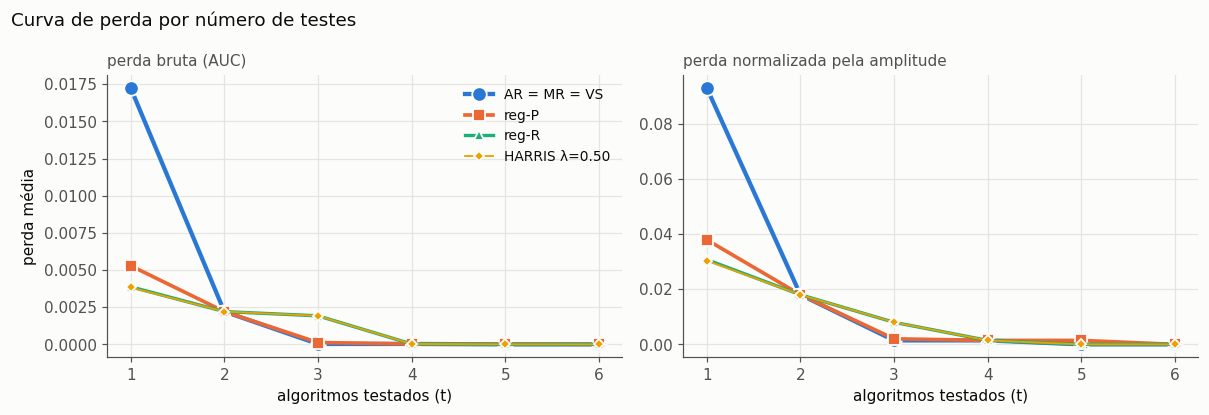

In [26]:
identicas = [k for k in SEIS if k in ("AR", "MR", "VS")
             and np.allclose(spearman[k], spearman["AR"])]
rotulo_agregacao = " = ".join(identicas) if len(identicas) > 1 else "AR"
mostrar = [rotulo_agregacao] + [k for k in SEIS if k not in identicas]

# as curvas treinadas quase coincidem: forma propria e tamanho decrescente na ordem de desenho,
# para o marcador de cima cair dentro do de baixo em vez de esconde-lo
MARCADORES, TAMANHOS, LARGURAS = ["o", "s", "^", "D"], [9.5, 8.0, 6.5, 4.5], [2.8, 2.4, 2.2, 1.2]

figura, eixos = plt.subplots(1, 2, figsize=(11, 3.8))
t = np.arange(1, n_algos + 1)

for eixo, dados, titulo in ((eixos[0], curvas, "perda bruta (AUC)"),
                            (eixos[1], curvas_norm, "perda normalizada pela amplitude")):
    for cor, marcador, tamanho, largura, nome_abordagem in zip(
            SERIES, MARCADORES, TAMANHOS, LARGURAS, mostrar):
        chave = identicas[0] if nome_abordagem == rotulo_agregacao else nome_abordagem
        eixo.plot(t, dados[chave], color=cor, lw=largura, marker=marcador, ms=tamanho,
                  markeredgecolor=SUPERFICIE, markeredgewidth=1.2, label=nome_abordagem)
    eixo.set_xlabel("algoritmos testados (t)")
    eixo.set_title(titulo, fontsize=10, color=TINTA_2, loc="left")
    eixo.set_xticks(t)
eixos[0].set_ylabel("perda média")
eixos[0].legend(frameon=False, fontsize=9)
figura.suptitle("Curva de perda por número de testes", x=0.005, ha="left", fontsize=12)
figura.tight_layout()
plt.show()

Quadro 7 — efeito do lambda no HARRIS
 lambda  spearman   area  area_norm
   0.00    0.7903 0.0012     0.0089
   0.25    0.7894 0.0014     0.0100
   0.50    0.7895 0.0013     0.0096
   0.75    0.7912 0.0015     0.0102
   1.00    0.7841 0.0015     0.0102


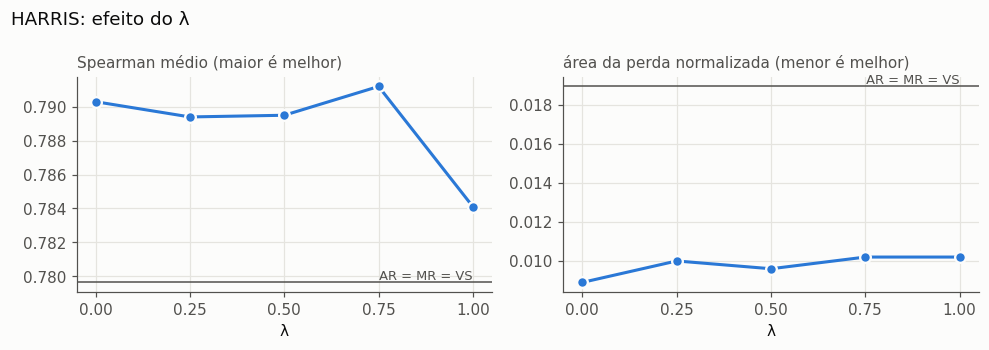

In [27]:
varredura = pd.DataFrame({
    "lambda": LAMBDAS,
    "spearman": [spearman[f"HARRIS λ={lam:.2f}"].mean() for lam in LAMBDAS],
    "area": [curvas[f"HARRIS λ={lam:.2f}"].mean() for lam in LAMBDAS],
    "area_norm": [curvas_norm[f"HARRIS λ={lam:.2f}"].mean() for lam in LAMBDAS],
}).round(4)
print("Quadro 7 — efeito do lambda no HARRIS")
print(varredura.to_string(index=False))

referencia = {"spearman": spearman[identicas[0]].mean(),
              "area_norm": curvas_norm[identicas[0]].mean()}

figura, eixos = plt.subplots(1, 2, figsize=(9, 3.2))
for eixo, coluna, titulo in ((eixos[0], "spearman", "Spearman médio (maior é melhor)"),
                             (eixos[1], "area_norm", "área da perda normalizada (menor é melhor)")):
    eixo.plot(varredura["lambda"], varredura[coluna], color=SERIES[0], lw=2, marker="o", ms=7,
              markeredgecolor=SUPERFICIE, markeredgewidth=1.5)
    eixo.axhline(referencia[coluna], color=TINTA_2, lw=1)  # a variacao do lambda so faz sentido contra a agregacao
    eixo.text(1.0, referencia[coluna], f" {rotulo_agregacao}", ha="right", va="bottom",
              fontsize=8.5, color=TINTA_2)
    eixo.set_xlabel("λ")
    eixo.set_xticks(LAMBDAS)
    eixo.set_title(titulo, fontsize=10, color=TINTA_2, loc="left")
figura.suptitle("HARRIS: efeito do λ", x=0.005, ha="left", fontsize=12)
figura.tight_layout()
plt.show()

## 3.2 Diagrama de diferença crítica

Friedman sobre a matriz 33 × 6 de Spearman por dataset, seguido de Nemenyi.

`CD = q_α · sqrt(k(k+1) / 6N)`, com k=6, N=33 e q₀.₀₅=2.850. Abordagens ligadas pela barra
horizontal não diferem significativamente.

Friedman: chi2 = 18.070, p = 2.86e-03
CD (Nemenyi, k=6, N=33, alfa=0.05) = 1.313

AR               3.273
MR               3.273
VS               3.273
reg-R            3.439
HARRIS λ=0.50    3.470
reg-P            4.273


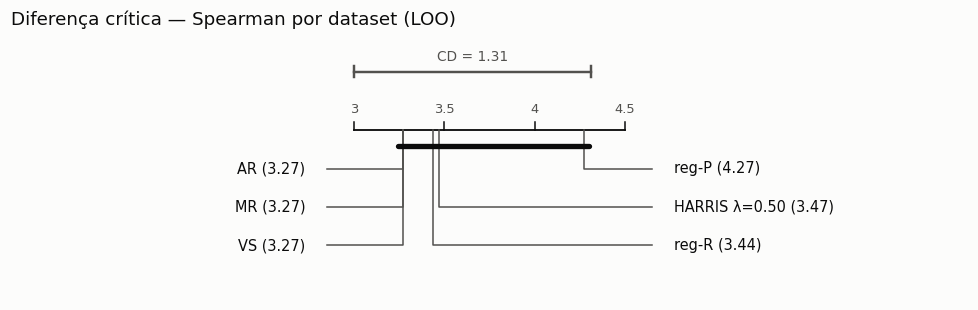

In [28]:
Q_NEMENYI = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850,
             7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164}


def diagrama_dc(ranks_medios, cd, titulo):
    nomes = np.array(ranks_medios.index)[np.argsort(ranks_medios.to_numpy())]
    valores = np.sort(ranks_medios.to_numpy())
    k = len(nomes)
    inicio, fim = np.floor(valores.min() * 2) / 2, np.ceil(valores.max() * 2) / 2
    metade, passo = (k + 1) // 2, 0.34

    figura, eixo = plt.subplots(figsize=(9, 1.9 + passo * metade))
    eixo.set_xlim(inicio - 1.9, fim + 1.9)
    eixo.set_ylim(-passo * (metade + 1.4), 0.85)
    eixo.axis("off")

    eixo.plot([inicio, fim], [0, 0], color=TINTA, lw=1.2)
    for marca in np.arange(inicio, fim + 1e-9, 0.5):
        eixo.plot([marca, marca], [0, 0.07], color=TINTA, lw=1.0)
        eixo.text(marca, 0.13, f"{marca:g}", ha="center", va="bottom", fontsize=8.5, color=TINTA_2)

    for j, (nome, valor) in enumerate(zip(nomes, valores)):
        esquerda = j < metade
        y = -passo * ((j + 1) if esquerda else (k - j))
        ponta = inicio - 0.15 if esquerda else fim + 0.15
        eixo.plot([valor, valor, ponta], [0, y, y], color=TINTA_2, lw=1.0)
        eixo.text(ponta + (-0.12 if esquerda else 0.12), y, f"{nome} ({valor:.2f})",
                  ha="right" if esquerda else "left", va="center", fontsize=9.5, color=TINTA)

    grupos = []
    for i in range(k):
        j = i
        while j + 1 < k and valores[j + 1] - valores[i] <= cd:
            j += 1
        if j > i:
            grupos.append((i, j))
    grupos = [g for g in grupos
              if not any(h != g and h[0] <= g[0] and g[1] <= h[1] for h in grupos)]

    for nivel, (i, j) in enumerate(grupos):
        y = -passo * (0.42 + 0.30 * nivel)
        eixo.plot([valores[i] - 0.03, valores[j] + 0.03], [y, y], color=TINTA, lw=3.5,
                  solid_capstyle="round")

    eixo.plot([inicio, inicio + cd], [0.52, 0.52], color=TINTA_2, lw=1.6)
    for ponta in (inicio, inicio + cd):
        eixo.plot([ponta, ponta], [0.47, 0.57], color=TINTA_2, lw=1.6)
    eixo.text(inicio + cd / 2, 0.62, f"CD = {cd:.2f}", ha="center", fontsize=9, color=TINTA_2)
    eixo.set_title(titulo, loc="left", fontsize=12, pad=6)
    figura.tight_layout()
    return figura


scores = pd.DataFrame({k: spearman[k] for k in SEIS})
estatistica, p_friedman = stats.friedmanchisquare(*scores.to_numpy().T)
ranks_por_dataset = np.array([_ranquear(-linha) for linha in scores.to_numpy()])
ranks_medios = pd.Series(ranks_por_dataset.mean(axis=0), index=SEIS)

k, N = len(SEIS), len(scores)
cd = Q_NEMENYI[k] * np.sqrt(k * (k + 1) / (6 * N))

print(f"Friedman: chi2 = {estatistica:.3f}, p = {p_friedman:.2e}")
print(f"CD (Nemenyi, k={k}, N={N}, alfa=0.05) = {cd:.3f}\n")
print(ranks_medios.sort_values().round(3).to_string())

diagrama_dc(ranks_medios, cd, "Diferença crítica — Spearman por dataset (LOO)")
plt.show()

## 3.3 Evidência para a interpretação

Os números que sustentam a discussão do relatório.

In [29]:
tri = {a: previsoes[previsoes.abordagem == a].sort_values("did")[algoritmos].to_numpy()
       for a in ("AR", "MR", "VS")}
iguais = sum(np.array_equal(tri["AR"][i], tri["MR"][i]) and np.array_equal(tri["AR"][i], tri["VS"][i])
             for i in range(n_datasets))

quadro_agregacao = pd.DataFrame({"vitórias": V.sum(), "mediana do rank": R.median(),
                                 "rank médio": R.mean().round(2)}).sort_values("vitórias", ascending=False)

print(f"Quadro 8 — por que AR, MR e VS coincidem: ranking identico em {iguais}/{n_datasets} rodadas")
quadro_agregacao

Quadro 8 — por que AR, MR e VS coincidem: ranking identico em 33/33 rodadas


,vitórias,mediana do rank,rank médio
hgb,131,1.5,1.77
rf,123,2.0,1.91
logreg,79,3.5,3.33
knn,64,4.0,3.85
nb,28,5.0,4.85
tree,18,5.5,5.29


In [30]:
def _recomendado(nome):
    g = previsoes[previsoes.abordagem == nome].sort_values("did").set_index("did")[algoritmos]
    return g.idxmin(axis=1)

quadro_discordancia = pd.DataFrame({
    "AR": _recomendado("AR"),
    "reg-R": _recomendado("reg-R"),
    "melhor real": P.idxmax(axis=1).reset_index(level="nome", drop=True),
    "nome": P.index.get_level_values("nome")})
quadro_discordancia = quadro_discordancia[quadro_discordancia.AR != quadro_discordancia["reg-R"]]

acertos = {"AR": int((quadro_discordancia.AR == quadro_discordancia["melhor real"]).sum()),
           "reg-R": int((quadro_discordancia["reg-R"] == quadro_discordancia["melhor real"]).sum())}
print(f"Quadro 9 — os {len(quadro_discordancia)} datasets em que AR e reg-R discordam no 1o lugar. "
      f"Acertos: AR {acertos['AR']}, reg-R {acertos['reg-R']}")
quadro_discordancia[["nome", "AR", "reg-R", "melhor real"]]

Quadro 9 — os 8 datasets em que AR e reg-R discordam no 1o lugar. Acertos: AR 4, reg-R 2


,nome,AR,reg-R,melhor real
did,,,,
30,page-blocks,hgb,rf,rf
151,electricity,hgb,rf,hgb
183,abalone,hgb,rf,logreg
300,isolet,hgb,rf,logreg
1497,wall-robot-navigation,hgb,rf,hgb
40685,shuttle,hgb,rf,rf
41027,jungle_chess_2pcs_raw_endgame_complete,hgb,rf,hgb
41138,APSFailure,hgb,rf,hgb


In [31]:
quadro_estabilidade = pd.DataFrame(
    {"rank médio": R.mean().round(2), "desvio": R.std().round(2),
     "melhor rank": R.min(), "pior rank": R.max(),
     "vezes no topo": (R.to_numpy() == R.min(axis=1).to_numpy()[:, None]).sum(axis=0)},
    index=R.columns).sort_values("rank médio")

print("Quadro 10 — estabilidade de cada algoritmo ao longo dos 33 datasets")
quadro_estabilidade

Quadro 10 — estabilidade de cada algoritmo ao longo dos 33 datasets


,rank médio,desvio,melhor rank,pior rank,vezes no topo
hgb,1.77,1.34,1.0,6.0,26
rf,1.91,0.65,1.0,4.5,14
logreg,3.33,1.20,1.0,6.0,5
knn,3.85,0.83,3.0,6.0,0
nb,4.85,1.09,1.5,6.0,1
tree,5.29,0.90,2.0,6.0,0


In [32]:
dominado = np.isin(P.idxmax(axis=1).to_numpy(), ["hgb", "rf"])


def _perda_t1(nome):
    g = previsoes[previsoes.abordagem == nome].sort_values("did")[algoritmos].to_numpy()
    return np.array([Pn[i].max() - Pn[i][np.argsort(g[i], kind="stable")[0]]
                     for i in range(n_datasets)])


quadro_dificuldade = pd.DataFrame(
    {f"ensemble vence ({dominado.sum()})": {nome: _perda_t1(nome)[dominado].mean() for nome in SEIS},
     f"outro vence ({(~dominado).sum()})": {nome: _perda_t1(nome)[~dominado].mean() for nome in SEIS}}
).round(4)

print("Quadro 11 — perda@1 separada por dificuldade do dataset. Os que fogem do padrao: "
      + ", ".join(P.index[i][1] for i in np.where(~dominado)[0]))
quadro_dificuldade

Quadro 11 — perda@1 separada por dificuldade do dataset. Os que fogem do padrao: waveform-5000, abalone, isolet, numerai28.6


,ensemble vence (29),outro vence (4)
AR,0.0146,0.0367
MR,0.0146,0.0367
VS,0.0146,0.0367
reg-P,0.0034,0.0189
reg-R,0.0018,0.0189
HARRIS λ=0.50,0.0018,0.0187


In [33]:
folga = ranks_medios.max() - ranks_medios.min()
print(f"Friedman chi2 = {estatistica:.2f}, p = {p_friedman:.2e} -> rejeita a nula")
print(f"maior diferenca de rank medio {folga:.3f} | CD = {cd:.3f} -> "
      f"{'nenhum par separa' if folga <= cd else 'ha pares separados'}")

Friedman chi2 = 18.07, p = 2.86e-03 -> rejeita a nula
maior diferenca de rank medio 1.000 | CD = 1.313 -> nenhum par separa
